In [ ]:
#include <iostream>

using namespace std;

int main()
{
    cout << "hello world. I'm " << 23 << " today" << endl;
    short a=0;
    long b=0;
    unsigned char c='1';
    u_int t=300;//快捷写法
    char d=200;
    cout<<"short:"<<sizeof(a)<<endl;
    cout<<"long:"<<sizeof(b)<<endl;
    cout <<"c:" << (int)d << endl;
    cout<<"char:"<<sizeof(d)<<endl;

    /*实型
    
        全部有符号*/
    return 0;
}

hello world. I'm 23 today

short:2

long:8

c:-56

char:1



In [32]:
#include <iostream>

using namespace std;

int main()
{
    /*实型
    
        全部有符号*/
    cout<<fixed;
    cout << "hello world. I'm " << 23 << " today" << endl;
    float a=1.2658181845450;
    double b=51616.0156516584521;
    string num;
    cout<<"float:"<<sizeof(a)<<endl;
    cin>>num;
    cout<<num<<endl;
    cout<<"double:"<<sizeof(b)<<endl;
    cout<<"a:"<<a<<endl;
    cout<<"b:"<<b<<endl;


    
    return 0;
}

hello world. I'm 23 today

float:4



代码2

double:8

a:1.265818

b:51616.015652



In [ ]:
//发工资
#include <iostream>

using namespace std;

int main()
{
    int total=10000;
    for(int i=1;i<=20;i++){
        

        if(total<=0){
            cout<<"员工"<<i<<"工资不够发"<<endl;
            break;
            
        }
        else{
            
            cout<<"员工"<<i<<"发工资"<<"1000"<<endl;
            
            total-=1000;
            goto lable1;
        }
    }
    
        


    
    return 0;
}

当前存款10000

员工1发工资1000

当前存款9000

员工1发工资1000

当前存款8000

员工1发工资1000

当前存款7000

员工1发工资1000

当前存款6000

员工1发工资1000

当前存款5000

员工1发工资1000

当前存款4000

员工1发工资1000

当前存款3000

员工1发工资1000

当前存款2000

员工1发工资1000

当前存款1000

员工1发工资1000

当前存款0

员工1工资不够发



## goto
break 只能跳出一层循环，goto 能一次跳到底。标签放最后、前后都用 return 隔开，避免程序"顺序执行"掉进标签后面的代码

In [51]:
#include <iostream>
using namespace std;

int main()
{
    int a[3][4] = {
        { 1,  2,  3,  4},
        { 5,  6,  7,  8},
        { 9, 10, 11, 12}
    };
    int target = 12;
    int ri = -1, ci = -1;

    for (int i = 0; i < 3; ++i)
        for (int j = 0; j < 4; ++j)
            if (a[i][j] == target)
            {
                ri = i;
                ci = j;
                goto found;          // 一次跳出两层循环
            }

    cout << "没找到" << endl;
    return 0;

found:                                // 标签写在最后
    cout << "找到了：a[" << ri << "][" << ci << "] = " << a[ri][ci] << endl;
    return 0;
}


找到了：a[2][3] = 12



## 指针
**指向常量的指针**  const 数据类型* 数据   const int* p = 5;


const指针：数据类型* const 数据     int* const p = &num；


指向const的const指针：

野指针：被声明但未初始化（赋值）的指针。这个指针会指向随机的内存空间，可能导致未知的问题

避免野指针的四条规则
1) 定义时立刻初始化：int* p = nullptr;
2) delete 之后立刻置 nullptr
3) 绝不返回局部变量的地址（要返回就用 new 或智能指针）
4) 现代 C++ 优先用智能指针，几乎不用手写 delete

In [55]:
#include <iostream>
using namespace std;

// 只读访问：参数用「指向常量的指针」，向调用者承诺不修改数据
void printAll(const int* data, int n)
{
    for (int i = 0; i < n; ++i)
        cout << data[i] << ' ';
    cout << endl;
    // data[0] = 99;        // 编译错误：不能通过 const int* 修改所指内容
    // data++;              // 合法：指针本身可以移动
}

int main()
{
    int       a = 10;
    int       b = 20;
    const int c = 30;

    // ============================================================
    // 一、指向常量的指针：const int* p
    //     指针能改指向，但不能通过它改值
    // ============================================================
    const int* p1 = &a;
    cout << "*p1 = " << *p1 << endl;       // 10
    // *p1 = 11;                           // 编译错误：assignment of read-only location
    p1 = &b;                               // 合法：改指向
    p1 = &c;                               // 合法：也能指向真正的 const 对象
    cout << "*p1 = " << *p1 << endl;       // 30

    // ============================================================
    // 二、常量指针：int* const p
    //     指针本身不能改指向（必须初始化），但可以通过它改值
    // ============================================================
    int* const p2 = &a;
    *p2 = 111;                             // 合法：改值
    cout << "a = " << a << endl;           // 111
    // p2 = &b;                            // 编译错误：assignment of read-only variable

    // ============================================================
    // 三、两个都锁死：const int* const p
    // ============================================================
    const int* const p3 = &b;
    cout << "*p3 = " << *p3 << endl;       // 20
    // *p3 = 5;                            // 编译错误
    // p3 = &a;                            // 编译错误

    // ============================================================
    // 四、最常用场景：函数参数 const int*
    // ============================================================
    int arr[5] = {1, 2, 3, 4, 5};
    printAll(arr, 5);                      // int* 可以直接传给 const int*

    // ============================================================
    // 五、类型转换规则（加 const 安全，去 const 危险）
    // ============================================================
    const int* r1 = &a;                    // 合法：int* → const int*
    (void)r1;
    // int* r2 = &c;                       // 编译错误：const int* → int* 会丢掉只读保护
    int* r2 = const_cast<int*>(&c);        // 强转能编过，但改它就是 UB，绝不能这么干
    cout << "*r2 = " << *r2 << endl;       // 30（只读是安全的）
    (void)r2;

    // ============================================================
    // 六、读法口诀：从变量名往左读，const 离谁近就修饰谁
    // ============================================================
    // int* p                p 是「指向 int 的指针」
    // const int* p          指向「const int」的指针    → const 修饰 int
    // int* const p          「const 的指针」，指向 int  → const 修饰 p
    // const int* const p    const 的指针，指向 const int

    return 0;
}


*p1 = 10

*p1 = 30

a = 111

*p3 = 20

1 2 3 4 5 

*r2 = 30



In [53]:
#include <iostream>
#include <memory>
using namespace std;

int main()
{
    // ============================================================
    // 一、空指针（nullptr）：不指向任何对象的指针
    // ============================================================
    int* p1 = nullptr;              // C++11 起用 nullptr，别用 0 或 NULL
    // *p1 = 10;                    // 危险！解引用空指针 → 程序崩溃（段错误）

    if (p1 == nullptr)              // 使用前先判空，这是好习惯
    {
        cout << "p1 是空指针，不能解引用" << endl;
    }

    int x = 42;
    p1 = &x;                        // 让它指向一个真实存在的对象
    if (p1 != nullptr)              // 等价写法：if (p1)
    {
        cout << "*p1 = " << *p1 << endl;
    }

    // ============================================================
    // 二、野指针：指向“无效内存”的指针（三种典型来源）
    // ============================================================

    // --- 来源 1：只声明、不初始化 ---
    // int* p2;                     // 局部变量未初始化，值就是随机的垃圾地址
    // *p2 = 10;                    // 危险！往随机地址写数据 → 段错误 / 破坏其他数据
    int* p2 = nullptr;              // 正确做法：还不知道指向谁就先置空

    // --- 来源 2：内存已释放，指针还留着（悬垂指针 dangling pointer）---
    int* p3 = new int(5);
    cout << "*p3 = " << *p3 << endl;
    delete p3;                      // 内存已归还给系统
    // cout << *p3 << endl;         // 危险！p3 现在指向已释放的内存
    p3 = nullptr;                   // 正确做法：delete 之后立刻置空

    // --- 来源 3：指向已销毁的局部变量 ---
    // int* bad() { int local = 10; return &local; }   // 局部变量出函数即销毁
    // int* p4 = bad();             // p4 成了野指针

    // ============================================================
    // 三、指针越界访问，本质也是野指针
    // ============================================================
    int arr[3] = {1, 2, 3};
    int* p5 = arr;                  // 数组名退化为 &arr[0]
    for (int i = 0; i < 3; ++i)
    {
        cout << "arr[" << i << "] = " << *(p5 + i) << endl;   // 合法范围 0~2
    }
    // p5[3] = 99;                  // 危险！越界写，属于未定义行为(UB)

    

    delete p2;                      // 删空指针是安全的（什么也不做）
    // delete p3;                   // 不能重复 delete 同一块内存（double free）

    // ============================================================
    // 五、现代替代方案：智能指针（自己管内存，不会忘 delete）
    // ============================================================
    unique_ptr<int> up = make_unique<int>(7);   // C++14
    cout << "*up = " << *up << endl;            // 7
    // 离开作用域自动释放，不用也不能手动 delete

    return 0;
}


p1 是空指针，不能解引用

*p1 = 42

*p3 = 5

arr[0] = 1

arr[1] = 2

arr[2] = 3

*up = 7



## 动态内存分配
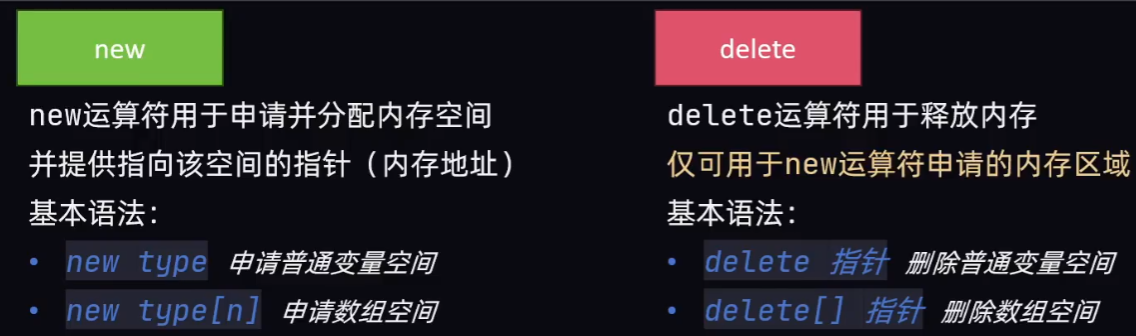

In [54]:
#include <iostream>
#include <memory>
#include <vector>
using namespace std;

int main()
{
    // ============================================================
    // 一、分配单个对象：new / delete
    // ============================================================
    int* p = new int(42);            // 在【堆】上分配 1 个 int，并初始化为 42
    cout << "*p = " << *p << endl;

    *p = 100;                        // 当成普通变量用
    cout << "*p = " << *p << endl;

    delete p;                        // 必须手动释放
    p = nullptr;                     // 立刻置空，避免变野指针

    // ============================================================
    // 二、分配数组：new[] / delete[]（必须配对）
    // ============================================================
    int n = 5;
    int* arr = new int[n];           // n 可以是运行期才确定的变量，这正是堆分配的意义
    for (int i = 0; i < n; ++i)
        arr[i] = (i + 1) * 10;       // arr[i] 等价于 *(arr + i)

    for (int i = 0; i < n; ++i)
        cout << arr[i] << ' ';
    cout << endl;

    delete[] arr;                    // 数组必须用 delete[]，不能用 delete
    arr = nullptr;

    // 带初始化列表的数组（C++11）
    int* b = new int[3]{1, 2, 3};
    cout << b[0] << b[1] << b[2] << endl;
    delete[] b;
    b = nullptr;

    // ============================================================
    // 三、动态二维数组：先分配行指针，再分配每行
    // ============================================================
    int rows = 2, cols = 3;
    int** grid = new int*[rows];
    for (int i = 0; i < rows; ++i)
        grid[i] = new int[cols];

    for (int i = 0; i < rows; ++i)
        for (int j = 0; j < cols; ++j)
            grid[i][j] = i * cols + j;

    for (int i = 0; i < rows; ++i)
    {
        for (int j = 0; j < cols; ++j)
            cout << grid[i][j] << ' ';
        cout << endl;
    }

    for (int i = 0; i < rows; ++i)
        delete[] grid[i];            // 释放顺序与分配顺序相反
    delete[] grid;
    grid = nullptr;

    // ============================================================
    // 四、常见错误（全部注释掉，别真跑）
    // ============================================================
    // int* q = new int[10];
    // delete q;                     // 错！new[] 必须配 delete[]，否则未定义行为
    // delete q;                     // 错！同一块内存 delete 两次 → double free 崩溃
    // int* r = new int(1); delete r; cout << *r;  // 错！释放后还访问（悬垂指针）
    // int* s; *s = 1;               // 错！野指针，没分配就直接写
    // while (true) { int* leak = new int[1000]; } // 内存泄漏：只分配不释放

    // ============================================================
    // 五、现代 C++ 的正确姿势：让对象自己管内存
    // ============================================================
    unique_ptr<int> up = make_unique<int>(7);   // 独占所有权
    cout << "*up = " << *up << endl;            // 出作用域自动 delete，无需手动释放

    vector<int> v(n, 1);                        // 动态数组首选 vector
    v.push_back(99);
    cout << "v.size() = " << v.size() << ", v.back() = " << v.back() << endl;

    vector<vector<int>> m(2, vector<int>(3, 0));   // 多维首选嵌套 vector
    m[1][2] = 5;
    cout << "m[1][2] = " << m[1][2] << endl;

    return 0;
}


*p = 42

*p = 100

10 20 30 40 50 

123

0 1 2 

3 4 5 

*up = 7

v.size() = 6, v.back() = 99

m[1][2] = 5

